# Fish GNN Baseline

Minimal GNN that predicts **acceleration only** from current state `(x, v)`.

Key inductive bias baked in from derivative analysis:
- **Edge features are relative state** `(xⱼ − xᵢ, vⱼ − vᵢ)` — encodes the empirical finding that jerk ~ relative velocity of neighbors
- Single output head (acceleration), order-2 integration
- No history window, no jerk term

Loss: `L = ||x_pred − x_true||² / σ_x² + λ_a * ||a_pred − a_true||² / σ_a²`

The acceleration term gives the network a direct gradient signal without relying on the tiny O(dt²) position contribution.

In [23]:
import numpy as np
import torch
import torch.nn as nn
import h5py
from scipy.ndimage import binary_dilation
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
DATA_PATH  = "data/skeleton_28dpf_v1 complete_500_002_testinference.000_rlt_250731_v0.analysis.h5"
FOCUS_NODE = 2       # body_1
FPS        = 25
DT         = 1.0 / FPS
N_FISH     = 4
NAN_MARGIN = 10
TRAIN_FRAC = 0.8

# Savitzky-Golay smoothing before finite differences
# Window must be odd; polynomial order < window
SAVGOL_WINDOW = 11   # ~0.44s at 25fps
SAVGOL_POLY   = 3

HIDDEN_DIM = 64
LR         = 1e-3
N_EPOCHS   = 200
BATCH_SIZE = 256
LAMBDA_A   = 1.0    # weight on normalized acceleration loss
GRAD_CLIP  = 1.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [24]:
# ── Load & Preprocess ─────────────────────────────────────────────────────────
with h5py.File(DATA_PATH, 'r') as f:
    tracks     = f['tracks'][:]                            # (4, 2, 6, T)
    node_names = [n.decode() for n in f['node_names'][:]]

pos_all = tracks.transpose(3, 0, 2, 1)                    # (T, fish, node, xy)
pos_raw = pos_all[:, :, FOCUS_NODE, :].copy()             # (T, fish, 2)
T_total = pos_raw.shape[0]
print(f"Frames: {T_total}  |  Fish: {N_FISH}  |  Node: {node_names[FOCUS_NODE]}")


def interpolate_nans(arr):
    """Linear interpolation over NaN gaps, per fish per axis."""
    out = arr.copy()
    for fi in range(arr.shape[1]):
        for d in range(arr.shape[2]):
            x = arr[:, fi, d]
            t = np.arange(len(x))
            valid = np.isfinite(x)
            if valid.sum() > 1:
                out[:, fi, d] = np.interp(t, t[valid], x[valid])
    return out


def make_nan_mask(pos_raw, margin=10):
    """True for frames within `margin` of any NaN gap."""
    nan_frames = np.any(np.isnan(pos_raw), axis=(1, 2))
    return binary_dilation(nan_frames, iterations=margin)


def smooth_positions(pos, window, poly):
    """
    Savitzky-Golay filter along time axis, per fish per axis.
    Suppresses noise amplification in finite-difference derivatives.
    Raw positions are preserved for rollout evaluation; smoothed
    positions are used only to compute v and a training targets.
    """
    out = pos.copy()
    for fi in range(pos.shape[1]):
        for d in range(pos.shape[2]):
            out[:, fi, d] = savgol_filter(pos[:, fi, d], window, poly)
    return out


pos_interp = interpolate_nans(pos_raw)
bad_frames = make_nan_mask(pos_raw, margin=NAN_MARGIN)

# Smooth interpolated positions for derivative estimation
pos_smooth = smooth_positions(pos_interp, SAVGOL_WINDOW, SAVGOL_POLY)

# Central finite differences on smoothed positions
vel = np.gradient(pos_smooth, DT, axis=0)   # (T, fish, 2)
acc = np.gradient(vel,        DT, axis=0)   # (T, fish, 2)

# Use smoothed positions as inputs/targets too (consistent with derivatives)
pos_clean = pos_smooth

print(f"Bad frames (near NaN gaps): {bad_frames.sum()}  ({100*bad_frames.mean():.1f}%)")

# Quick sanity check: compare raw vs smoothed acceleration std
acc_raw  = np.gradient(np.gradient(pos_interp, DT, axis=0), DT, axis=0)
print(f"Accel std — raw FD: {acc_raw.std():.2f} px/s²  |  after SG: {acc.std():.2f} px/s²")

Frames: 14510  |  Fish: 4  |  Node: body_1
Bad frames (near NaN gaps): 227  (1.6%)
Accel std — raw FD: 289.99 px/s²  |  after SG: 77.09 px/s²


In [25]:
# ── Build Dataset ─────────────────────────────────────────────────────────────
# Each sample: (x_t, v_t) → (x_{t+1}, a_t)
# No history window — current state only.

T_train = int(T_total * TRAIN_FRAC)


def build_dataset(pos, vel, acc, bad):
    samples = []
    T = pos.shape[0]
    for t in range(T - 1):
        if bad[t] or bad[t + 1]:
            continue
        samples.append((
            torch.tensor(pos[t],   dtype=torch.float32),   # x_t   (N_FISH, 2)
            torch.tensor(vel[t],   dtype=torch.float32),   # v_t   (N_FISH, 2)
            torch.tensor(pos[t+1], dtype=torch.float32),   # x_tp1 (N_FISH, 2)
            torch.tensor(acc[t],   dtype=torch.float32),   # a_t   (N_FISH, 2)
        ))
    return samples


train_data = build_dataset(
    pos_clean[:T_train], vel[:T_train], acc[:T_train], bad_frames[:T_train])
test_data  = build_dataset(
    pos_clean[T_train:], vel[T_train:], acc[T_train:], bad_frames[T_train:])

print(f"Train samples: {len(train_data)}  |  Test samples: {len(test_data)}")

# Normalization constants (from training data only)
pos_arr = np.stack([s[0].numpy() for s in train_data])   # (N, fish, 2)
acc_arr = np.stack([s[3].numpy() for s in train_data])

SIGMA_X = float(pos_arr.std()) + 1e-8
SIGMA_A = float(acc_arr.std()) + 1e-8
print(f"sigma_x = {SIGMA_X:.4f} px  |  sigma_a = {SIGMA_A:.4f} px/s²")

Train samples: 11491  |  Test samples: 2784
sigma_x = 202.4630 px  |  sigma_a = 76.7275 px/s²


In [26]:
# ── Data Loader ───────────────────────────────────────────────────────────────
# Fully-connected directed graph (excluding self-loops)
_rows, _cols = zip(*[(i, j) for i in range(N_FISH) for j in range(N_FISH) if i != j])
BASE_EDGE_INDEX = torch.tensor([_rows, _cols], dtype=torch.long)   # (2, N_FISH*(N_FISH-1))
N_EDGES = BASE_EDGE_INDEX.shape[1]


def collate(batch):
    """Tile edge_index across batch; flatten node dimension."""
    B = len(batch)
    x_t, v_t, x_tp1, a_t = zip(*batch)

    x_t   = torch.stack(x_t)    # (B, N_FISH, 2)
    v_t   = torch.stack(v_t)
    x_tp1 = torch.stack(x_tp1)
    a_t   = torch.stack(a_t)

    # Offset edge indices for each graph in the batch
    offsets = torch.arange(B, dtype=torch.long).unsqueeze(1) * N_FISH   # (B, 1)
    edge_index = (BASE_EDGE_INDEX.unsqueeze(0) + offsets.unsqueeze(1))  # (B, 2, E)
    edge_index = edge_index.permute(1, 0, 2).reshape(2, -1)             # (2, B*E)

    return (
        x_t.view(B * N_FISH, 2),
        v_t.view(B * N_FISH, 2),
        x_tp1.view(B * N_FISH, 2),
        a_t.view(B * N_FISH, 2),
        edge_index,
    )


train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate)
test_loader  = torch.utils.data.DataLoader(
    test_data,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

In [27]:
# ── Model ─────────────────────────────────────────────────────────────────────

class FishBaselineGNN(nn.Module):
    """
    Single-round message-passing GNN: v → a.

    Absolute position removed from node features — the governing equation
    j_i = f(v_j - v_i, x_j - x_i) has no absolute position term.
    Relative geometry lives entirely in edge features.

    Node encoder : vᵢ(2) → hᵢ (hidden_dim)
    Message net  : [hᵢ, hⱼ, xⱼ−xᵢ(2), vⱼ−vᵢ(2)] → mᵢⱼ (hidden_dim)
    Update net   : [hᵢ, mean(mᵢⱼ)] → hᵢ' (hidden_dim), residual
    Output head  : hᵢ' → aᵢ (2)
    """

    def __init__(self, hidden_dim: int = 64):
        super().__init__()
        self.node_enc = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.ReLU()   # velocity only (2D)
        )
        # message: h_i(H) + h_j(H) + rel_pos(2) + rel_vel(2) = 2H+4
        self.msg_net = nn.Sequential(
            nn.Linear(2 * hidden_dim + 4, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),         nn.ReLU(),
        )
        # update: h_i(H) + agg(H) = 2H
        self.update_net = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.acc_head = nn.Linear(hidden_dim, 2)

    def forward(
        self,
        x_pos: torch.Tensor,       # (B*N, 2)  — used only for edge features
        x_vel: torch.Tensor,       # (B*N, 2)  — node features
        edge_index: torch.Tensor,  # (2, E)
    ) -> torch.Tensor:             # (B*N, 2)  — predicted acceleration

        h = self.node_enc(x_vel)                         # (B*N, H)

        src, dst = edge_index                            # src=j (sender), dst=i (receiver)
        h_i = h[dst]
        h_j = h[src]
        rel_pos = x_pos[src] - x_pos[dst]              # xⱼ − xᵢ  (E, 2)
        rel_vel = x_vel[src] - x_vel[dst]              # vⱼ − vᵢ  (E, 2)

        msg = self.msg_net(
            torch.cat([h_i, h_j, rel_pos, rel_vel], dim=-1)
        )                                               # (E, H)

        # Mean aggregation of incoming messages
        N = h.shape[0]
        agg = torch.zeros(N, msg.shape[-1], device=h.device)
        cnt = torch.zeros(N, 1,            device=h.device)
        agg.scatter_add_(0, dst.unsqueeze(1).expand_as(msg), msg)
        cnt.scatter_add_(0, dst.unsqueeze(1), torch.ones(dst.shape[0], 1, device=h.device))
        agg = agg / cnt.clamp(min=1)

        # Residual update
        h_new = h + self.update_net(torch.cat([h, agg], dim=-1))

        return self.acc_head(h_new)                     # (B*N, 2)


model = FishBaselineGNN(hidden_dim=HIDDEN_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")

Parameters: 25,410


In [28]:
# ── Training ──────────────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

history = {'train_total': [], 'train_x': [], 'train_a': [],
           'test_total':  [], 'test_x':  [], 'test_a':  []}


def run_epoch(loader, train: bool):
    model.train(train)
    totals = {'total': 0., 'x': 0., 'a': 0.}
    n_batches = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x_t, v_t, x_tp1, a_true, edge_index in loader:
            x_t, v_t, x_tp1, a_true = (
                x_t.to(device), v_t.to(device), x_tp1.to(device), a_true.to(device))
            edge_index = edge_index.to(device)

            a_pred = model(x_t, v_t, edge_index)                  # (B*N, 2)
            x_pred = x_t + v_t * DT + 0.5 * a_pred * DT**2       # order-2 integration

            loss_x = ((x_pred - x_tp1)**2).mean() / SIGMA_X**2
            loss_a = ((a_pred - a_true)**2).mean() / SIGMA_A**2
            loss   = loss_x + LAMBDA_A * loss_a

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            totals['total'] += loss.item()
            totals['x']     += loss_x.item()
            totals['a']     += loss_a.item()
            n_batches += 1

    return {k: v / n_batches for k, v in totals.items()}


print(f"{'Epoch':>6} | {'Train':>8} | {'Test':>8} | {'loss_x':>8} | {'loss_a':>8}")
print('-' * 50)

for epoch in range(1, N_EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    te = run_epoch(test_loader,  train=False)
    scheduler.step()

    for k in history:
        split, metric = k.split('_', 1)
        history[k].append((tr if split == 'train' else te)[metric])

    if epoch % 20 == 0 or epoch == 1:
        print(f"{epoch:>6} | {tr['total']:>8.4f} | {te['total']:>8.4f} "
              f"| {te['x']:>8.4f} | {te['a']:>8.4f}")

print("Done.")

 Epoch |    Train |     Test |   loss_x |   loss_a
--------------------------------------------------
     1 |   0.9998 |   1.0179 |   0.0000 |   1.0179
    20 |   0.9959 |   1.0172 |   0.0000 |   1.0172
    40 |   0.9727 |   1.0566 |   0.0000 |   1.0566
    60 |   0.9281 |   1.1378 |   0.0000 |   1.1378
    80 |   0.8950 |   1.2630 |   0.0000 |   1.2630
   100 |   0.8696 |   1.3468 |   0.0000 |   1.3468
   120 |   0.8518 |   1.3742 |   0.0000 |   1.3742
   140 |   0.8407 |   1.4104 |   0.0000 |   1.4104
   160 |   0.8341 |   1.4198 |   0.0000 |   1.4198
   180 |   0.8306 |   1.4274 |   0.0000 |   1.4274
   200 |   0.8297 |   1.4305 |   0.0000 |   1.4305
Done.


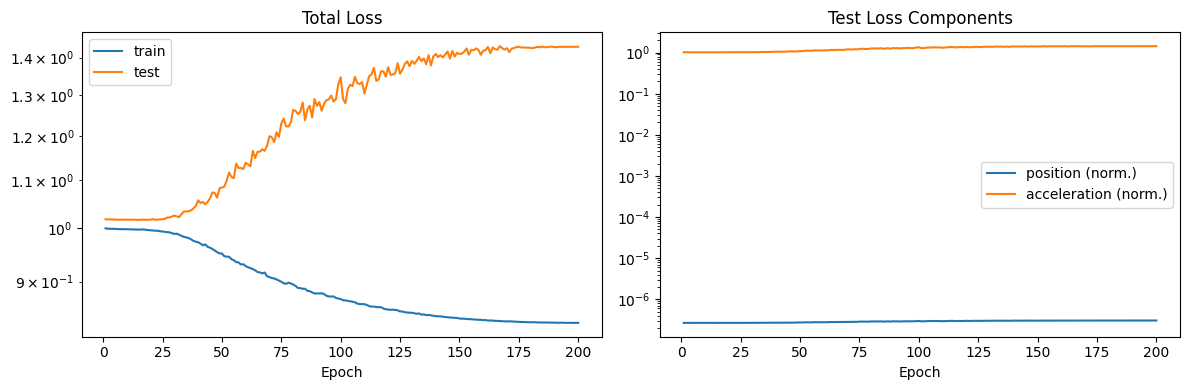

In [29]:
# ── Training Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, N_EPOCHS + 1)
axes[0].semilogy(epochs, history['train_total'], label='train')
axes[0].semilogy(epochs, history['test_total'],  label='test')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].semilogy(epochs, history['test_x'], label='position (norm.)')
axes[1].semilogy(epochs, history['test_a'], label='acceleration (norm.)')
axes[1].set_title('Test Loss Components')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

Acceleration x: r = 0.002  RMSE = 95.1105 px/s²
Acceleration y: r = 0.013  RMSE = 87.8646 px/s²


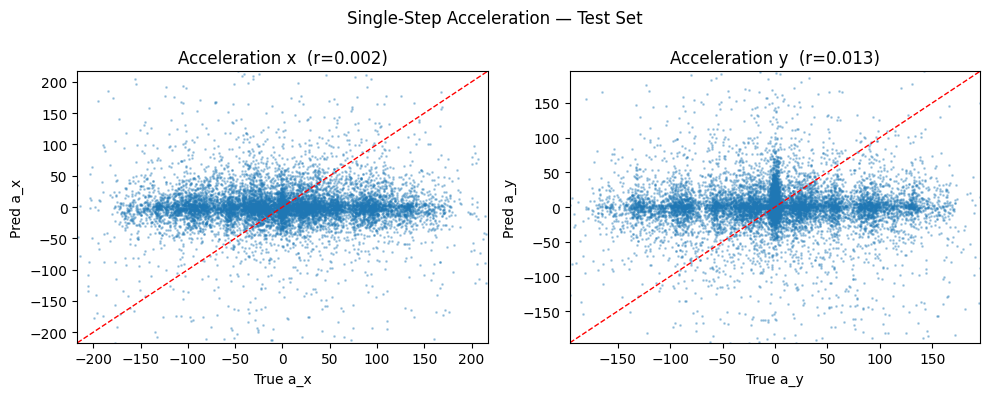


Single-step position RMSE: 0.1116 px


In [30]:
# ── Single-Step Evaluation ────────────────────────────────────────────────────
# Collect all test predictions in one pass
model.eval()
all_a_pred, all_a_true = [], []
all_x_pred, all_x_true = [], []

with torch.no_grad():
    for x_t, v_t, x_tp1, a_true, edge_index in test_loader:
        x_t, v_t = x_t.to(device), v_t.to(device)
        edge_index = edge_index.to(device)

        a_pred = model(x_t, v_t, edge_index).cpu()
        x_pred = (x_t + v_t * DT + 0.5 * a_pred.to(device) * DT**2).cpu()

        all_a_pred.append(a_pred)
        all_a_true.append(a_true)
        all_x_pred.append(x_pred)
        all_x_true.append(x_tp1)

a_pred_np = torch.cat(all_a_pred).numpy()
a_true_np = torch.cat(all_a_true).numpy()
x_pred_np = torch.cat(all_x_pred).numpy()
x_true_np = torch.cat(all_x_true).numpy()

# Pearson r per axis
for dim, label in enumerate(['x', 'y']):
    r, p = pearsonr(a_true_np[:, dim], a_pred_np[:, dim])
    rmse  = np.sqrt(np.mean((a_pred_np[:, dim] - a_true_np[:, dim])**2))
    print(f"Acceleration {label}: r = {r:.3f}  RMSE = {rmse:.4f} px/s²")

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (label, ax) in enumerate(zip(['x', 'y'], axes)):
    r, _ = pearsonr(a_true_np[:, i], a_pred_np[:, i])
    ax.scatter(a_true_np[:, i], a_pred_np[:, i], s=1, alpha=0.3)
    lim = np.percentile(np.abs(a_true_np[:, i]), 99)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.axline((0, 0), slope=1, color='r', ls='--', lw=1)
    ax.set_xlabel(f'True a_{label}'); ax.set_ylabel(f'Pred a_{label}')
    ax.set_title(f'Acceleration {label}  (r={r:.3f})')
plt.suptitle('Single-Step Acceleration — Test Set')
plt.tight_layout()
plt.show()

pos_rmse = np.sqrt(np.mean((x_pred_np - x_true_np)**2))
print(f"\nSingle-step position RMSE: {pos_rmse:.4f} px")

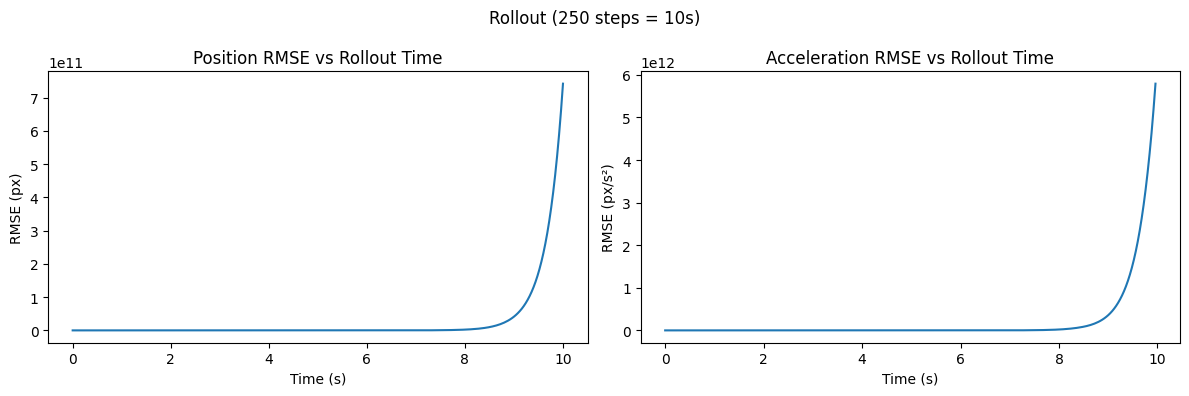

In [31]:
# ── Rollout Evaluation ────────────────────────────────────────────────────────
# Autoregressive rollout from a clean starting window in the test set.
# State: (x_t, v_t); integration: order-2 Euler.

ROLLOUT_START = 100    # frame offset into test set to start from
ROLLOUT_STEPS = 250    # ~10 seconds at 25fps

T_test_start = T_train + ROLLOUT_START

model.eval()
with torch.no_grad():
    x_curr = torch.tensor(pos_clean[T_test_start],     dtype=torch.float32)
    v_curr = torch.tensor(vel      [T_test_start],     dtype=torch.float32)

    rollout_x = [x_curr.numpy().copy()]
    rollout_a = []

    edge_index = BASE_EDGE_INDEX.to(device)   # (2, N_FISH*(N_FISH-1)) — single graph

    for step in range(ROLLOUT_STEPS):
        x_in = x_curr.to(device)
        v_in = v_curr.to(device)

        a_pred = model(x_in, v_in, edge_index).cpu()  # (N_FISH, 2)

        x_next = x_curr + v_curr * DT + 0.5 * a_pred * DT**2
        v_next = v_curr + a_pred * DT

        rollout_x.append(x_next.numpy().copy())
        rollout_a.append(a_pred.numpy().copy())
        x_curr, v_curr = x_next, v_next

rollout_x = np.stack(rollout_x)   # (steps+1, N_FISH, 2)
rollout_a = np.stack(rollout_a)   # (steps,   N_FISH, 2)

# True values for same window
true_x = pos_clean[T_test_start : T_test_start + ROLLOUT_STEPS + 1]   # (steps+1, N_FISH, 2)
true_a = acc      [T_test_start : T_test_start + ROLLOUT_STEPS]       # (steps,   N_FISH, 2)

# Per-step RMSE
rmse_x = np.sqrt(np.mean((rollout_x - true_x)**2, axis=(1, 2)))   # (steps+1,)
rmse_a = np.sqrt(np.mean((rollout_a - true_a)**2, axis=(1, 2)))   # (steps,)

t_axis = np.arange(ROLLOUT_STEPS + 1) / FPS

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_axis, rmse_x)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('RMSE (px)')
axes[0].set_title('Position RMSE vs Rollout Time')

axes[1].plot(t_axis[:-1], rmse_a)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('RMSE (px/s²)')
axes[1].set_title('Acceleration RMSE vs Rollout Time')

plt.suptitle(f'Rollout ({ROLLOUT_STEPS} steps = {ROLLOUT_STEPS/FPS:.0f}s)')
plt.tight_layout()
plt.show()

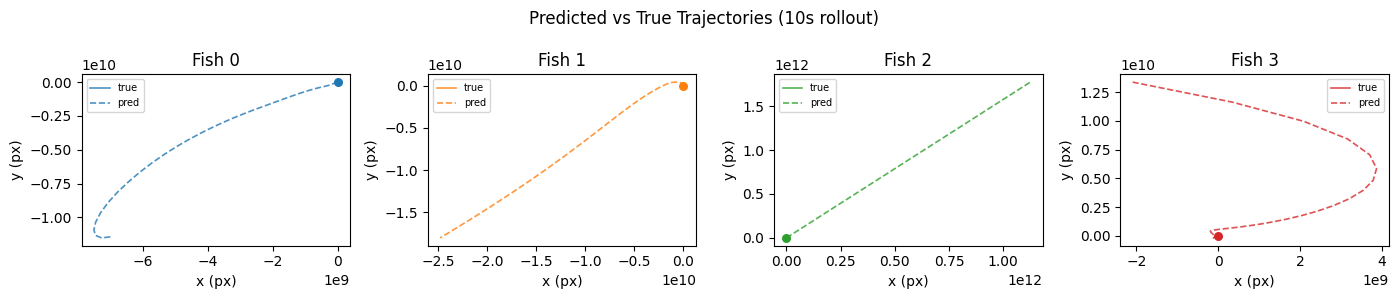

In [32]:
# ── Rollout Trajectories ──────────────────────────────────────────────────────
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
fig, axes = plt.subplots(1, N_FISH, figsize=(14, 3), sharex=False, sharey=False)

for fi in range(N_FISH):
    ax = axes[fi]
    ax.plot(true_x[:, fi, 0],    true_x[:, fi, 1],    color=colors[fi], lw=1.2,
            label='true', alpha=0.8)
    ax.plot(rollout_x[:, fi, 0], rollout_x[:, fi, 1], color=colors[fi], lw=1.2,
            ls='--', label='pred', alpha=0.8)
    ax.scatter(*true_x[0, fi],    marker='o', color=colors[fi], zorder=5, s=30)
    ax.set_title(f'Fish {fi}')
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    ax.legend(fontsize=7)

plt.suptitle(f'Predicted vs True Trajectories ({ROLLOUT_STEPS/FPS:.0f}s rollout)')
plt.tight_layout()
plt.show()

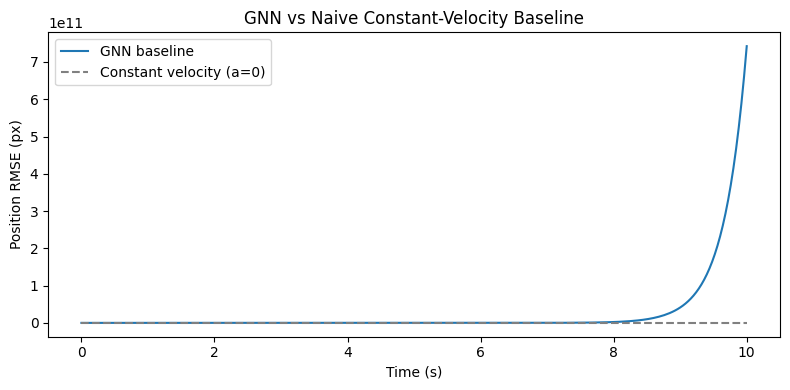

GNN   final RMSE: 742392572528.30 px
Const final RMSE: 130.27 px


In [33]:
# ── Naive Baseline: constant-velocity (a=0) ───────────────────────────────────
# Useful floor: what RMSE do we get if we just predict a=0 everywhere?
x_cv = pos_clean[T_test_start].copy()
v_cv = vel[T_test_start].copy()
cv_x = [x_cv.copy()]
for _ in range(ROLLOUT_STEPS):
    x_cv = x_cv + v_cv * DT    # a=0
    cv_x.append(x_cv.copy())
cv_x = np.stack(cv_x)

rmse_cv = np.sqrt(np.mean((cv_x - true_x)**2, axis=(1, 2)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_axis, rmse_x,  label='GNN baseline')
ax.plot(t_axis, rmse_cv, label='Constant velocity (a=0)', ls='--', color='gray')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Position RMSE (px)')
ax.set_title('GNN vs Naive Constant-Velocity Baseline')
ax.legend()
plt.tight_layout()
plt.show()

print(f"GNN   final RMSE: {rmse_x[-1]:.2f} px")
print(f"Const final RMSE: {rmse_cv[-1]:.2f} px")